# Automatidata Portfolio Project
## Predicting Generous Tippers from NYC Yellow Taxi Trip Data

This notebook is my portfolio rewrite of the Automatidata project.

I used official NYC Open Data and built a full classification workflow in Colab.
To keep the notebook practical and reproducible, I downloaded a manageable public-data slice from the 2017 Yellow Taxi dataset instead of using the full table.

The target is whether a credit-card trip ended with a tip rate of 20% or higher.

In [ ]:
# Install xgboost for the tree-based comparison model
!pip -q install xgboost

In [ ]:
# Import libraries and set display options
import io
import requests
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42

## PACE: Plan

The original business request can push drivers away from certain riders.
For this portfolio version, I use a less problematic target:
**generous tipper = tip rate >= 20%**.

This still supports revenue analysis, but avoids directly profiling riders as "bad customers."

In [ ]:
# Define the official dataset endpoint and a helper to pull a reproducible Colab-sized slice
DATASET_PAGE = "https://data.cityofnewyork.us/Transportation/2017-Yellow-Taxi-Trip-Data/biws-g3hs/about_data"
API_ENDPOINT = "https://data.cityofnewyork.us/resource/biws-g3hs.csv"

# Optional: add your Socrata app token here if you hit rate limits
APP_TOKEN = None

selected_columns = [
    "vendorid",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "ratecodeid",
    "pulocationid",
    "dolocationid",
    "payment_type",
    "fare_amount",
    "tip_amount",
    "tolls_amount",
    "total_amount"
]

def fetch_month_chunk(start_date: str, end_date: str, limit: int = 15000) -> pd.DataFrame:
    params = {
        "$select": ",".join(selected_columns),
        "$where": (
            f"tpep_pickup_datetime >= '{start_date}T00:00:00' "
            f"AND tpep_pickup_datetime < '{end_date}T00:00:00'"
        ),
        "$limit": limit
    }
    headers = {"X-App-Token": APP_TOKEN} if APP_TOKEN else {}
    response = requests.get(API_ENDPOINT, params=params, headers=headers, timeout=120)
    response.raise_for_status()

    return pd.read_csv(
        io.StringIO(response.text),
        parse_dates=["tpep_pickup_datetime", "tpep_dropoff_datetime"]
    )

In [ ]:
# Pull data in monthly chunks so the notebook stays reproducible in Colab
month_starts = pd.date_range("2017-01-01", "2017-12-01", freq="MS")
rows_per_month = 15000

parts = []
for start in month_starts:
    end = start + pd.DateOffset(months=1)
    part = fetch_month_chunk(
        start.strftime("%Y-%m-%d"),
        end.strftime("%Y-%m-%d"),
        limit=rows_per_month
    )
    parts.append(part)

df_raw = pd.concat(parts, ignore_index=True).drop_duplicates().sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (180000, 13)


,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,pulocationid,dolocationid,payment_type,fare_amount,tip_amount,tolls_amount,total_amount
0,1,2017-09-01 00:15:35,2017-09-01 00:25:35,1,2.20,1,230,158,1,9.0,2.05,0.00,12.35
1,2,2017-09-01 01:00:36,2017-09-01 01:08:05,1,1.30,1,113,158,1,7.0,1.66,0.00,9.96
2,2,2017-03-01 00:07:08,2017-03-01 00:29:38,1,6.08,1,163,157,1,21.5,4.56,0.00,27.36
3,1,2017-02-01 02:00:02,2017-02-01 02:05:00,1,1.10,1,181,181,1,6.5,1.55,0.00,9.35
4,1,2017-05-01 00:47:48,2017-05-01 01:06:50,1,5.60,1,186,112,2,20.0,0.00,5.76,27.06


In [ ]:
# Inspect data types and missingness
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180000 entries, 0 to 179999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   vendorid               180000 non-null  int64         
 1   tpep_pickup_datetime   180000 non-null  datetime64[ns]
 2   tpep_dropoff_datetime  180000 non-null  datetime64[ns]
 3   passenger_count        180000 non-null  int64         
 4   trip_distance          180000 non-null  float64       
 5   ratecodeid             180000 non-null  int64         
 6   pulocationid           180000 non-null  int64         
 7   dolocationid           180000 non-null  int64         
 8   payment_type           180000 non-null  int64         
 9   fare_amount            180000 non-null  float64       
 10  tip_amount             180000 non-null  float64       
 11  tolls_amount           180000 non-null  float64       
 12  total_amount           180000 non-null  floa

## PACE: Analyze

This version is self-contained and runs directly from official NYC Open Data.

I rebuilt the workflow from scratch instead of using the course CSV files from earlier lessons.
I also kept only **credit-card trips**, because tip values are more reliable there than in cash transactions.

This makes the target more consistent for modeling, but it also means the final model is only meant for the credit-card subset of the data.

In [ ]:
# Clean the data and keep only rows that make sense for tip modeling
df = df_raw.copy()

# Credit card only because tip values are recorded there more reliably
df = df[df["payment_type"] == 1].copy()

# Basic validity filters
df = df.dropna(subset=[
    "vendorid", "tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
    "trip_distance", "ratecodeid", "pulocationid", "dolocationid",
    "fare_amount", "tip_amount", "total_amount"
])

df = df[df["total_amount"] > df["tip_amount"]].copy()
df = df[df["fare_amount"] > 0].copy()
df = df[df["trip_distance"] > 0].copy()
df = df[df["passenger_count"].between(1, 6)].copy()

# Trip duration
df["duration_minutes"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

df = df[df["duration_minutes"].between(1, 180)].copy()
df = df[df["fare_amount"].between(2.5, 200)].copy()

print("Filtered shape:", df.shape)

Filtered shape: (116748, 14)


In [ ]:
# Create the target and core time-based features
df["tip_percent"] = np.round(df["tip_amount"] / (df["total_amount"] - df["tip_amount"]), 3)
df["generous"] = (df["tip_percent"] >= 0.20).astype(int)

df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_day"] = df["tpep_pickup_datetime"].dt.day_name().str.lower()
df["pickup_month"] = df["tpep_pickup_datetime"].dt.strftime("%b").str.lower()
df["is_weekend"] = df["pickup_day"].isin(["saturday", "sunday"]).astype(int)

df["am_rush"] = df["pickup_hour"].between(6, 9).astype(int)
df["daytime"] = df["pickup_hour"].between(10, 15).astype(int)
df["pm_rush"] = df["pickup_hour"].between(16, 19).astype(int)
df["nighttime"] = (~df["pickup_hour"].between(6, 19)).astype(int)

df[["tip_percent", "generous", "pickup_hour", "pickup_day", "pickup_month"]].head()

,tip_percent,generous,pickup_hour,pickup_day,pickup_month
0,0.199,0,0,friday,sep
1,0.200,1,1,friday,sep
2,0.200,1,0,wednesday,mar
3,0.199,0,2,wednesday,feb
5,0.000,0,0,friday,dec


In [ ]:
# Add portfolio-style engineered features
df["speed_mph"] = df["trip_distance"] / (df["duration_minutes"] / 60)
df["speed_mph"] = df["speed_mph"].replace([np.inf, -np.inf], np.nan).clip(lower=0, upper=80)

df["round5_ratio"] = ((np.ceil(df["fare_amount"] / 5) * 5) - df["fare_amount"]) / df["fare_amount"]
df["round10_ratio"] = ((np.ceil(df["fare_amount"] / 10) * 10) - df["fare_amount"]) / df["fare_amount"]

df["distance_bin"] = pd.cut(
    df["trip_distance"],
    bins=[0, 1, 3, 7, np.inf],
    labels=["short", "medium", "long", "very_long"],
    right=False
)

df["fare_bin"] = pd.cut(
    df["fare_amount"],
    bins=[0, 10, 20, 35, np.inf],
    labels=["low", "mid", "high", "very_high"],
    right=False
)

df[["speed_mph", "round5_ratio", "round10_ratio", "distance_bin", "fare_bin"]].head()

,speed_mph,round5_ratio,round10_ratio,distance_bin,fare_bin
0,13.200000,0.111111,0.111111,medium,low
1,10.423163,0.428571,0.428571,medium,low
2,16.213333,0.162791,0.395349,long,high
3,13.288591,0.538462,0.538462,medium,low
5,7.142857,0.333333,0.333333,medium,low


In [ ]:
# Reduce very high-cardinality location columns into top groups
top_pu = df["pulocationid"].value_counts().nlargest(40).index
top_do = df["dolocationid"].value_counts().nlargest(40).index

df["pulocation_group"] = df["pulocationid"].astype(str).where(df["pulocationid"].isin(top_pu), "other")
df["dolocation_group"] = df["dolocationid"].astype(str).where(df["dolocationid"].isin(top_do), "other")
df["vendorid"] = df["vendorid"].astype(str)
df["ratecodeid"] = df["ratecodeid"].astype(str)

In [ ]:
# Keep modeling columns and review class balance
model_df = df[[
    "generous",
    "vendorid",
    "ratecodeid",
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "duration_minutes",
    "speed_mph",
    "pickup_hour",
    "pickup_day",
    "pickup_month",
    "is_weekend",
    "am_rush",
    "daytime",
    "pm_rush",
    "nighttime",
    "round5_ratio",
    "round10_ratio",
    "distance_bin",
    "fare_bin",
    "pulocation_group",
    "dolocation_group"
]].copy()

print(model_df["generous"].value_counts(normalize=True).rename("share"))
model_df.head()

generous
1    0.526639
0    0.473361
Name: share, dtype: float64


,generous,vendorid,ratecodeid,passenger_count,trip_distance,fare_amount,duration_minutes,speed_mph,pickup_hour,pickup_day,pickup_month,is_weekend,am_rush,daytime,pm_rush,nighttime,round5_ratio,round10_ratio,distance_bin,fare_bin,pulocation_group,dolocation_group
0,0,1,1,1,2.20,9.0,10.000000,13.200000,0,friday,sep,0,0,0,0,1,0.111111,0.111111,medium,low,230,158
1,1,2,1,1,1.30,7.0,7.483333,10.423163,1,friday,sep,0,0,0,0,1,0.428571,0.428571,medium,low,113,158
2,1,2,1,1,6.08,21.5,22.500000,16.213333,0,wednesday,mar,0,0,0,0,1,0.162791,0.395349,long,high,163,other
3,0,1,1,1,1.10,6.5,4.966667,13.288591,2,wednesday,feb,0,0,0,0,1,0.538462,0.538462,medium,low,other,181
5,0,2,1,1,1.00,7.5,8.400000,7.142857,0,friday,dec,0,0,0,0,1,0.333333,0.333333,medium,low,107,186


## PACE: Construct

I use three models in this portfolio version:

- Logistic Regression as a simple baseline
- Random Forest
- XGBoost

I also use a train / validation / test split.
That keeps final model selection away from the test set.

In [ ]:
# Split the data into train, validation, and test
X = model_df.drop(columns="generous")
y = model_df["generous"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, y_train.shape)
print("Valid:", X_valid.shape, y_valid.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (70048, 21) (70048,)
Valid: (23350, 21) (23350,)
Test : (23350, 21) (23350,)


In [ ]:
# Build preprocessing and helper functions
numeric_features = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "duration_minutes",
    "speed_mph",
    "pickup_hour",
    "is_weekend",
    "am_rush",
    "daytime",
    "pm_rush",
    "nighttime",
    "round5_ratio",
    "round10_ratio"
]

categorical_features = [
    "vendorid",
    "ratecodeid",
    "pickup_day",
    "pickup_month",
    "distance_bin",
    "fare_bin",
    "pulocation_group",
    "dolocation_group"
]

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

def score_model(model_name, fitted_model, X_data, y_data):
    preds = fitted_model.predict(X_data)
    return pd.DataFrame({
        "model": [model_name],
        "precision": [precision_score(y_data, preds)],
        "recall": [recall_score(y_data, preds)],
        "f1": [f1_score(y_data, preds)],
        "accuracy": [accuracy_score(y_data, preds)]
    })

In [ ]:
# Fit a logistic regression baseline
logreg_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

logreg_pipe.fit(X_train, y_train)
logreg_valid_results = score_model("Logistic Regression", logreg_pipe, X_valid, y_valid)
logreg_valid_results

,model,precision,recall,f1,accuracy
0,Logistic Regression,0.705632,0.754981,0.729473,0.705096


In [ ]:
# Tune a random forest model
rf_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

rf_params = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5, 0.8]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_params,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("RF best params:", rf_search.best_params_)
print("RF best CV f1:", rf_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
RF best params: {'model__n_estimators': 400, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': 10}
RF best CV f1: 0.7669025020006703


In [ ]:
# Tune an XGBoost model
xgb_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        tree_method="hist",
        n_jobs=-1
    ))
])

xgb_params = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [4, 6, 8],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=xgb_params,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("XGB best params:", xgb_search.best_params_)
print("XGB best CV f1:", xgb_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
XGB best params: {'model__subsample': 1.0, 'model__n_estimators': 300, 'model__min_child_weight': 3, 'model__max_depth': 4, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}
XGB best CV f1: 0.7666586975580453


In [ ]:
# Compare models on the validation set and choose a champion
rf_valid_results = score_model("Random Forest", rf_search.best_estimator_, X_valid, y_valid)
xgb_valid_results = score_model("XGBoost", xgb_search.best_estimator_, X_valid, y_valid)

valid_results = pd.concat(
    [logreg_valid_results, rf_valid_results, xgb_valid_results],
    ignore_index=True
).sort_values("f1", ascending=False)

valid_results

,model,precision,recall,f1,accuracy
2,XGBoost,0.695970,0.851102,0.765758,0.725782
1,Random Forest,0.696412,0.849150,0.765234,0.725610
0,Logistic Regression,0.705632,0.754981,0.729473,0.705096


In [ ]:
# Refit the champion on train + validation, then evaluate once on the test set
champion_name = valid_results.iloc[0]["model"]

if champion_name == "Logistic Regression":
    champion_model = logreg_pipe
elif champion_name == "Random Forest":
    champion_model = rf_search.best_estimator_
else:
    champion_model = xgb_search.best_estimator_

X_train_full = pd.concat([X_train, X_valid], axis=0)
y_train_full = pd.concat([y_train, y_valid], axis=0)

champion_model.fit(X_train_full, y_train_full)

test_results = score_model(f"{champion_name} (test)", champion_model, X_test, y_test)
print("Champion model:", champion_name)
test_results

Champion model: XGBoost


,model,precision,recall,f1,accuracy
0,XGBoost (test),0.698691,0.846304,0.765446,0.726852


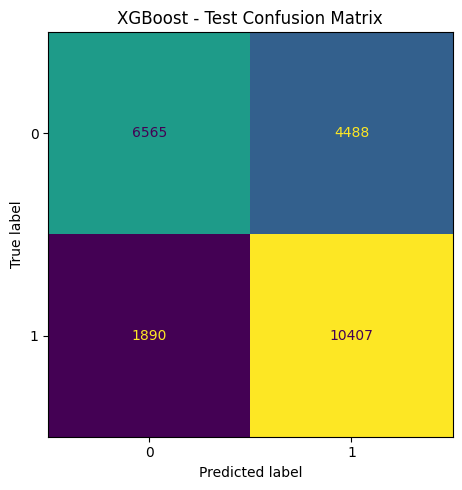

In [21]:
# Plot a confusion matrix for the final model with integer labels
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    champion_model,
    X_test,
    y_test,
    ax=ax,
    cmap="viridis",
    colorbar=False,
    values_format="d"
)
ax.set_title(f"{champion_name} - Test Confusion Matrix")
plt.tight_layout()
plt.show()

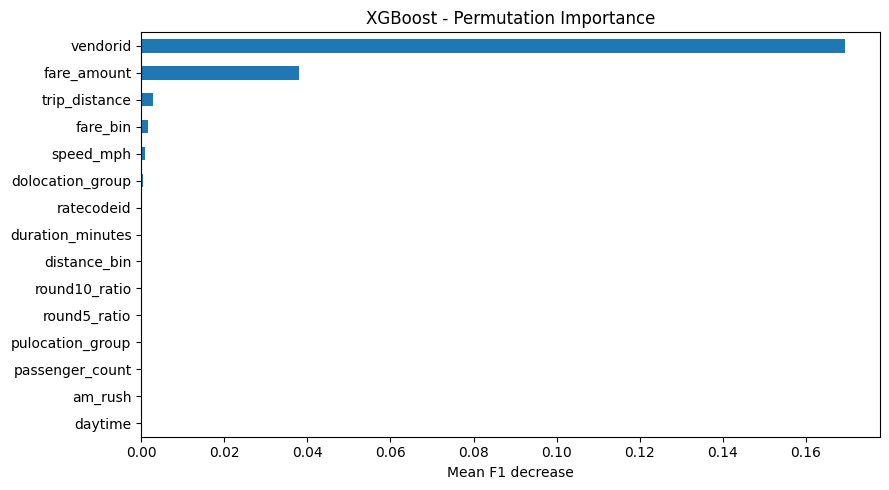

,0
vendorid,0.169431
fare_amount,0.037945
trip_distance,0.002736
fare_bin,0.001587
speed_mph,0.000984
dolocation_group,0.000354
ratecodeid,0.000248
duration_minutes,0.000244
distance_bin,0.000131
round10_ratio,0.000074


In [ ]:
# Show permutation importance on the final model for a more interpretable portfolio view
perm = permutation_importance(
    champion_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_importance = (
    pd.Series(perm.importances_mean, index=X_test.columns)
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 5))
perm_importance.sort_values().plot(kind="barh", ax=ax)
ax.set_title(f"{champion_name} - Permutation Importance")
ax.set_xlabel("Mean F1 decrease")
plt.tight_layout()
plt.show()

perm_importance.sort_values(ascending=False)

## PACE: Execute

### Final notes

This portfolio version follows the same business theme as the Automatidata project,
but it is built as a standalone notebook that runs directly from official NYC Open Data.

Main differences from the course exemplar:
- direct API download instead of local CSV files
- self-contained feature engineering
- grouped location categories to control feature explosion
- train / validation / test split for cleaner model selection
- model-agnostic permutation importance for interpretation

The final model should be treated as a practical prototype, not a production dispatch system.

Important limits:
- this notebook uses a public-data sample, not the full 2017 table
- the analysis only uses credit-card trips
- the validation gap between Random Forest and XGBoost is very small, so the final model was selected by a narrow margin
- `vendorid` appears much more important than other features, which may reflect a strong proxy pattern instead of a direct causal effect

The model has usable signal, but the results should be explained carefully and with clear limits.

In [ ]:
# Optional: save a few outputs for GitHub or a portfolio folder
valid_results.to_csv("validation_results.csv", index=False)
test_results.to_csv("test_results.csv", index=False)
perm_importance.rename("importance").to_csv("permutation_importance.csv")

print("Saved: validation_results.csv, test_results.csv, permutation_importance.csv")

Saved: validation_results.csv, test_results.csv, permutation_importance.csv


## Project Summary

In this project, I used the main ideas from the Google Advanced Data Analytics Automatidata scenario:
- PACE workflow
- ethical reframing of the target
- feature engineering for time, fare, and trip behavior
- classification modeling with tree-based methods
- model comparison with F1 score

I also updated the project in my own way:
- used official NYC Open Data directly in Colab
- built a full notebook without relying on course CSV files
- added a train / validation / test split
- added extra engineered features such as speed, fare bins, and round-up ratios
- used permutation importance for a simpler interpretation view

This version is designed as a public portfolio project that is easier to rerun, explain, and share on GitHub.

## Reference

This project was rewritten as an independent portfolio notebook.
The idea and scenario were **referenced from the Google Advanced Data Analytics Automatidata exemplar**,
but the code structure, data access method, feature engineering, model selection flow, and notebook writing were rebuilt for my own public portfolio version.